In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

master = pd.read_csv("../data/processed/master_ecommerce.csv", parse_dates=[
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

print(master.shape)
master.info()

(99441, 23)
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   is_delivered                   99441 non-null  bool          
 9   delivery_delay_days            96476 non-null  float64       
 10  customer_unique_id             99441 non-null  str           
 11  customer_zip_c

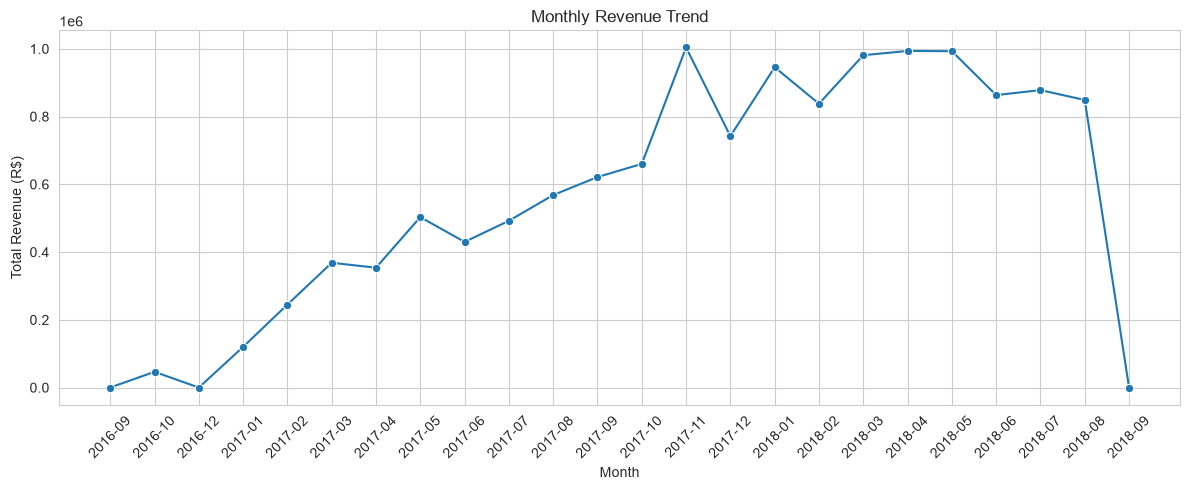

In [2]:
# Only look at delivered/valid orders for revenue analysis
valid_orders = master[master['order_status'] != 'canceled'].copy()
valid_orders['order_month'] = valid_orders['order_purchase_timestamp'].dt.to_period('M')

monthly_sales = valid_orders.groupby('order_month')['total_price'].sum().reset_index()
monthly_sales['order_month'] = monthly_sales['order_month'].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='order_month', y='total_price', marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.ylabel('Total Revenue (R$)')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

C:\Users\Anuj Diwakar\AppData\Local\Temp\ipykernel_5428\79390257.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.values, y=category_revenue.index, palette='viridis')


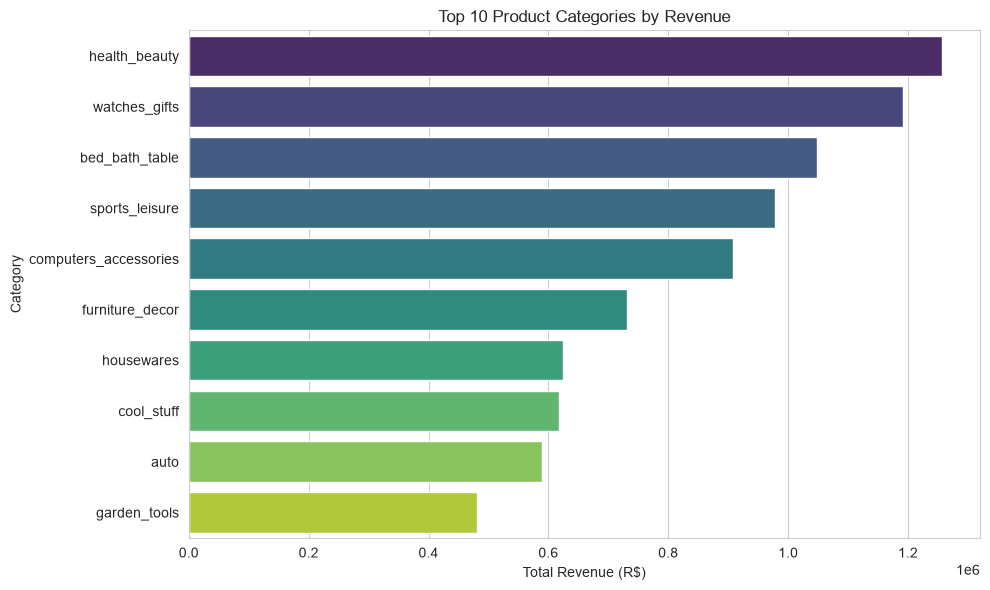

In [3]:
category_revenue = (
    valid_orders.groupby('main_category')['total_price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=category_revenue.values, y=category_revenue.index, palette='viridis')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Total Revenue (R$)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

C:\Users\Anuj Diwakar\AppData\Local\Temp\ipykernel_5428\2556014501.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_revenue.values, y=state_revenue.index, palette='mako')


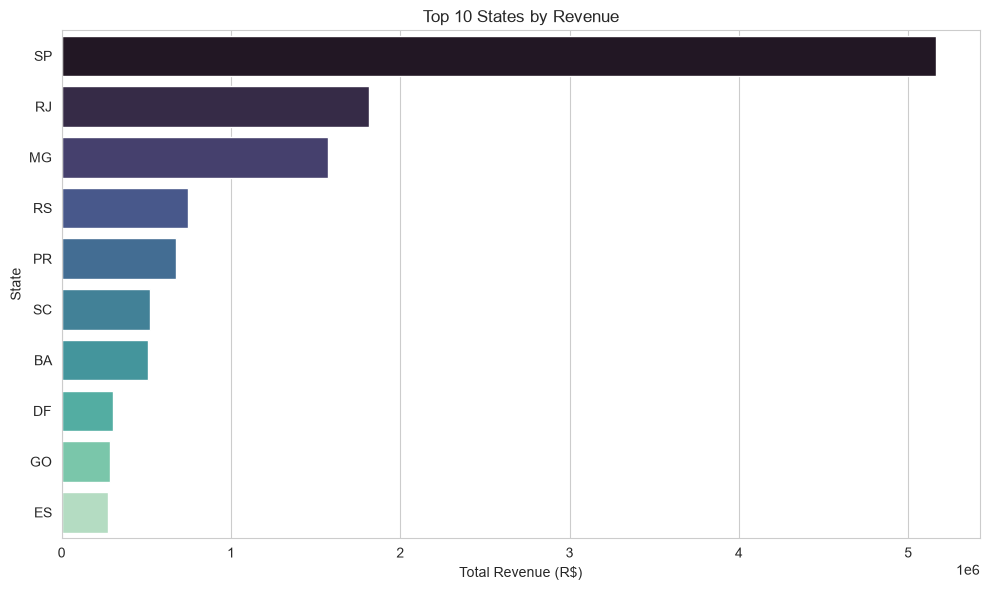

In [4]:
state_revenue = (
    valid_orders.groupby('customer_state')['total_price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=state_revenue.values, y=state_revenue.index, palette='mako')
plt.title('Top 10 States by Revenue')
plt.xlabel('Total Revenue (R$)')
plt.ylabel('State')
plt.tight_layout()
plt.show()